<a href="https://colab.research.google.com/github/shreyasat27/mahework2025/blob/main/Criteriafor_radicalpair.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.6/31.6 MB 60.8 MB/s eta 0:00:00


<>:182: SyntaxWarning: invalid escape sequence '\m'
<>:182: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-2682951894.py:182: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Time ($\mu s$)')


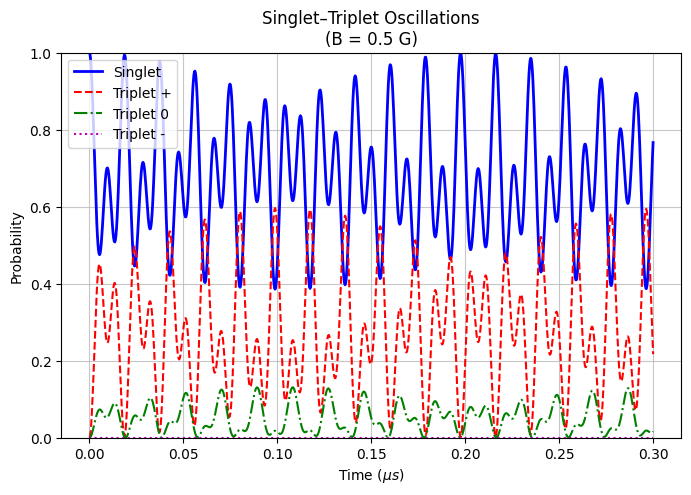

In [5]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.constants import hbar, electron_mass, elementary_charge

# =============================================================================
# 1. UNIT CONVERSION AND CONSTANTS
# =============================================================================
# Convert Gauss to MHz (Frequency). 1 G = 2.802 MHz
gauss_to_mhz = 2.802
# Convert MHz to energy units (rad MHz, since H/ħ defines frequency in MHz)
mhz_to_energy = 2 * np.pi  # So that energy = A_mhz * (operator) gives freq in MHz

# Gyromagnetic ratio for electron (gamma_e = -g_e * mu_B / ħ)
# g_e ~ 2.0023, mu_B / h = 1.3996 MHz/G, so |gamma_e| / (2π) ≈ 2.802 MHz/G
gamma_e_mhz_per_g = 2.802  # MHz/G

# =============================================================================
# 2. DEFINE THE HYPERFINE COUPLING CONSTANTS (Converted to MHz)
# =============================================================================
# Lumiflavin radical: N5 coupling - This represents the hyperfine interaction strength
# between the electron spin and nitrogen nucleus in the Lumiflavin molecule
A_lumi_G = 7.6  # Coupling in Gauss
A_lumi_mhz = A_lumi_G * gauss_to_mhz  # ~21.3 MHz

# Tryptophan radical: N1 coupling - Hyperfine coupling for the tryptophan molecule
A_trp_G = 3.0   # Coupling in Gauss
A_trp_mhz = A_trp_G * gauss_to_mhz    # ~8.41 MHz

# Exchange interaction (J) - Represents the magnetic interaction between two electron spins
# J is negative if singlet is lower in energy. For a separated pair, |J| is small.
# This is CRITICAL for DiVincenzo Criterion 4 (controllability)
J_value_mhz = -10.0  # MHz (Assumed value, often fitted from data)

# =============================================================================
# 3. DEFINE THE SPIN OPERATORS
# =============================================================================
# Each electron and nucleus is a spin-1/2 particle.
# We create a 4-spin system: Electron1 ⊗ Electron2 ⊗ Nucleus1 ⊗ Nucleus2

# Electron 1 (on Lumiflavin) - Spin operators for the first unpaired electron
Sx1 = qt.tensor(qt.sigmax(), qt.qeye(2), qt.qeye(2), qt.qeye(2))
Sy1 = qt.tensor(qt.sigmay(), qt.qeye(2), qt.qeye(2), qt.qeye(2))
Sz1 = qt.tensor(qt.sigmaz(), qt.qeye(2), qt.qeye(2), qt.qeye(2))
S1 = [Sx1, Sy1, Sz1]

# Electron 2 (on Tryptophan) - Spin operators for the second unpaired electron
Sx2 = qt.tensor(qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.qeye(2))
Sy2 = qt.tensor(qt.qeye(2), qt.sigmay(), qt.qeye(2), qt.qeye(2))
Sz2 = qt.tensor(qt.qeye(2), qt.sigmaz(), qt.qeye(2), qt.qeye(2))
S2 = [Sx2, Sy2, Sz2]

# Nucleus 1 (N5 on Lumiflavin) - Nuclear spin operators for nitrogen in Lumiflavin
Ix1 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.sigmax(), qt.qeye(2))
Iy1 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.sigmay(), qt.qeye(2))
Iz1 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.qeye(2))
I1 = [Ix1, Iy1, Iz1]

# Nucleus 2 (N1 on Tryptophan) - Nuclear spin operators for nitrogen in Tryptophan
Ix2 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.sigmax())
Iy2 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.sigmay())
Iz2 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.sigmaz())
I2 = [Ix2, Iy2, Iz2]

# =============================================================================
# 4. CONSTRUCT THE HAMILTONIAN TERMS - CORE PHYSICS FOR QUBIT OPERATION
# =============================================================================
# The full Hamiltonian: H = H_Zeeman + H_HF + H_ex
# This Hamiltonian defines how the qubit evolves in time - essential for DiVincenzo Criterion 4

def get_hamiltonian(B_field_gauss):
    """
    Constructs the full spin Hamiltonian for a given external magnetic field (in Gauss).
    This function models the three main interactions in a radical pair qubit system.
    """
    # Convert B field from Gauss to MHz (for Zeeman term frequency)
    omega_e_mhz = gamma_e_mhz_per_g * B_field_gauss  # Larmor precession frequency

    # -------------------------------------------------------------------------
    # A. Zeeman Hamiltonian (H_Z) - DiVincenzo Criterion 4 (Controllability)
    # Interaction of electrons with the external B field (assumed along z-axis)
    # H_Z = -gamma_e * B * (S_{z,1} + S_{z,2})
    # This term allows us to CONTROL the qubit using magnetic fields
    # -------------------------------------------------------------------------
    H_z = -omega_e_mhz * mhz_to_energy * (Sz1 + Sz2)
    # Note: We neglect nuclear Zeeman effect as it is much smaller (~kHz/G).

    # -------------------------------------------------------------------------
    # B. Hyperfine Hamiltonian (H_HF) - DiVincenzo Criterion 3 (Coherence)
    # H_HF = A1 * (S1·I1) + A2 * (S2·I2)
    # This term causes DECOHERENCE by coupling electron spins to nuclear spins
    # Strong hyperfine coupling = shorter coherence times = bad for qubit
    # -------------------------------------------------------------------------
    # For Lumiflavin electron (S1) with its nucleus (I1)
    H_hf1 = A_lumi_mhz * mhz_to_energy * (Sx1 * Ix1 + Sy1 * Iy1 + Sz1 * Iz1)
    # For Tryptophan electron (S2) with its nucleus (I2)
    H_hf2 = A_trp_mhz * mhz_to_energy * (Sx2 * Ix2 + Sy2 * Iy2 + Sz2 * Iz2)

    H_hf = H_hf1 + H_hf2

    # -------------------------------------------------------------------------
    # C. Exchange Interaction (H_ex) - DiVincenzo Criterion 1 & 4
    # H_ex = J * (S1·S2)
    # This term determines the energy splitting between singlet and triplet states
    # Small |J| = microwave-addressable qubit (good)
    # Large |J| = THz-frequency transitions (bad for control)
    # -------------------------------------------------------------------------
    H_ex = J_value_mhz * mhz_to_energy * (Sx1*Sx2 + Sy1*Sy2 + Sz1*Sz2)

    # -------------------------------------------------------------------------
    # Full Hamiltonian - The complete quantum description of our qubit candidate
    # -------------------------------------------------------------------------
    H_total = H_z + H_hf + H_ex

    return H_total

# =============================================================================
# 5. DEFINE THE INITIAL STATE AND OBSERVABLES - DiVincenzo Criterion 2 (Initialization)
# =============================================================================
# The initial state is the singlet state |S> = (|↑↓> - |↓↑>)/sqrt(2)
# This simulates starting with a well-defined quantum state (initialization)

# Create the electron singlet state vector
singlet_e = (qt.tensor(qt.basis(2,0), qt.basis(2,1)) - qt.tensor(qt.basis(2,1), qt.basis(2,0))).unit()
# Tensor with specific nuclear states, e.g., both nuclei spin-up |αα>
n_init = qt.tensor(qt.basis(2,0), qt.basis(2,0))
psi0 = qt.tensor(singlet_e, n_init)

# The singlet probability operator: P_S = |S><S| for electrons
# This is our measurement operator - DiVincenzo Criterion 5 (Readout)
singlet_proj = singlet_e * singlet_e.dag()
P_s = qt.tensor(singlet_proj, qt.qeye(2), qt.qeye(2))

# Triplet subspace = I_electron - singlet projector
triplet_proj = (qt.tensor(qt.qeye(2), qt.qeye(2)) - singlet_proj)
P_t = qt.tensor(triplet_proj, qt.qeye(2), qt.qeye(2))

# =============================================================================
# 6. TIME EVOLUTION AND PLOTTING - SIMULATING QUBIT DYNAMICS
# =============================================================================
# Choose a magnetic field (e.g., Earth's field ~0.5 G or stronger for clearer results)
B_field = 0.5  # Gauss
H_total = get_hamiltonian(B_field)

# Set a time list to simulate (microseconds)
tlist = np.linspace(0, 0.3, 1000)  # Simulate for 0.3 microseconds

# Time evolution: Solve the Schrödinger equation
# This simulates how the qubit state evolves naturally
result = qt.sesolve(H_total, psi0, tlist, e_ops=[P_s, P_t])

# -------------------------------------------------------------------------
# Define detailed electron basis states for better analysis
up = qt.basis(2, 0)
down = qt.basis(2, 1)

# Electron singlet and triplet states - These are our potential qubit states
singlet_e = (qt.tensor(up, down) - qt.tensor(down, up)).unit()
triplet_plus = qt.tensor(up, up)
triplet_zero = (qt.tensor(up, down) + qt.tensor(down, up)).unit()
triplet_minus = qt.tensor(down, down)

# Projectors for each state - Measurement operators for DiVincenzo Criterion 5
P_s  = qt.tensor(singlet_e * singlet_e.dag(), qt.qeye(2), qt.qeye(2))
P_tp = qt.tensor(triplet_plus * triplet_plus.dag(), qt.qeye(2), qt.qeye(2))
P_t0 = qt.tensor(triplet_zero * triplet_zero.dag(), qt.qeye(2), qt.qeye(2))
P_tm = qt.tensor(triplet_minus * triplet_minus.dag(), qt.qeye(2), qt.qeye(2))

# -------------------------------------------------------------------------
# Solve time evolution with all projectors as observables
# This gives us complete information about state populations over time
result = qt.sesolve(H_total, psi0, tlist, e_ops=[P_s, P_tp, P_t0, P_tm])

# -------------------------------------------------------------------------
# Plot results - Visualization of qubit coherence and dynamics
# The oscillation patterns tell us about coherence times and controllability
plt.figure(figsize=(8,5))
plt.plot(tlist, result.expect[0], 'b-',  label='Singlet', linewidth=2)
plt.plot(tlist, result.expect[1], 'r--', label='Triplet +')
plt.plot(tlist, result.expect[2], 'g-.', label='Triplet 0')
plt.plot(tlist, result.expect[3], 'm:', label='Triplet -')

plt.xlabel('Time ($\mu s$)')
plt.ylabel('Probability')
plt.title(f'Singlet–Triplet Oscillations\n(B = {B_field} G)')
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.7)
plt.show()

The triplet curves overlap strangely: red (T₊) seems to carry most of the “missing” probability, while green (T₀) and magenta (T₋) stay very small.

That could be right — depending on your Hamiltonian, hyperfine couplings, and field strength, only some triplets mix strongly with the singlet.

But if you expected all three triplets to have comparable weight, then something in your Hamiltonian/projectors might need a check.

The stacking effect in your plot (blue over red over green) suggests you might be using fill_between or plotting with high opacity. That makes it hard to visually separate them. If you want to see clearly, better to plot them as lines (no fill) or use a stacked area chart where each state has its own distinct band.

Include the extra hyperfine nuclei (Lumiflavin: N(5), N(10), H(9); Tryptophan: N(1), β–H, α–H) instead of only one nucleus per radical. Multiple nuclei produce more complex mixing and populate different triplet components differently.

Use an unpolarized (mixed) nuclear initial state rather than a single nuclear product state (|↑↑…⟩). Starting with a pure nuclear state biases which triplets get populated — the physically relevant approximation for radical pairs is usually a maximally mixed nuclear state (ρ_nuc = I/2^N), or averaging over nuclear configurations.

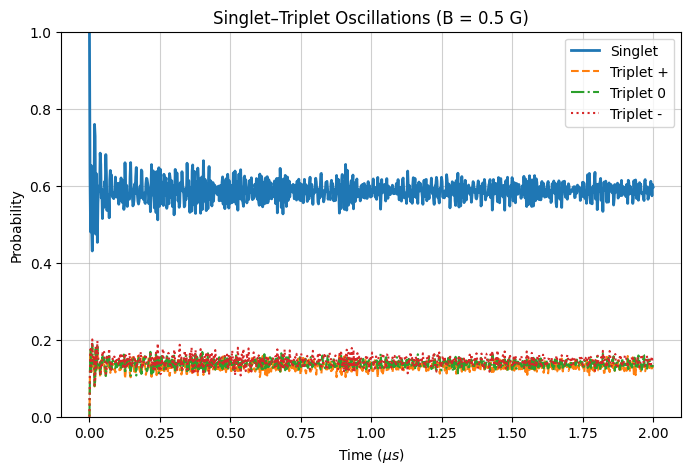

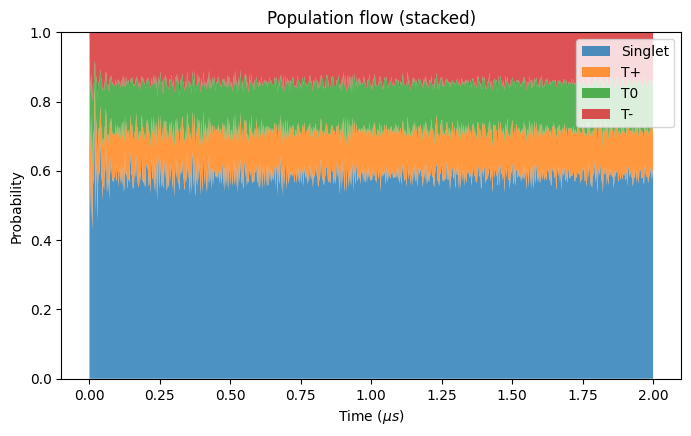

In [ ]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

# -------------------------
# conversion and constants
# -------------------------
gauss_to_mhz = 2.802                 # MHz per Gauss (|gamma_e|/2π)
mhz_to_energy = 2 * np.pi            # use ħ=1 units: multiply MHz by 2π to get rad·MHz

# -------------------------
# user hyperfine lists (Gauss) -- from your table
# -------------------------
# Lumiflavin nuclei (N5 ~7.6, N10 ~3.8, H9 ~7.7)
A_lumi_list_G = [7.6, 3.8, 7.7]      # add / remove entries as desired

# Tryptophan nuclei (N1 ~3.0, beta-H ~1.5, alpha-H ~0.8)
A_trp_list_G  = [3.0, 1.5, 0.8]

# Optional: trim lists for smaller Hilbert space during tests:
# A_lumi_list_G = [7.6, 3.8]
# A_trp_list_G  = [3.0]

# -------------------------
# construct spin operators for arbitrary number of nuclei
# Basis ordering: [e1, e2, nL1, nL2, ..., nR1, nR2, ...]
# -------------------------
n_lumi = len(A_lumi_list_G)
n_trp  = len(A_trp_list_G)
n_nuc = n_lumi + n_trp
N = 2 + n_nuc            # total spins (2 electrons + nuclei)
dim = 2**N

# helper to build single-spin operator at site idx
def spin_op_at(op, idx, N):
    ops = []
    for i in range(N):
        if i == idx:
            ops.append(op)
        else:
            ops.append(qt.qeye(2))
    return qt.tensor(ops)

# electron indices
idx_e1 = 0
idx_e2 = 1

# create electron spin operators (Sx, Sy, Sz) for both electrons
S1 = [spin_op_at(qt.sigmax(), idx_e1, N),
      spin_op_at(qt.sigmay(), idx_e1, N),
      spin_op_at(qt.sigmaz(), idx_e1, N)]
S2 = [spin_op_at(qt.sigmax(), idx_e2, N),
      spin_op_at(qt.sigmay(), idx_e2, N),
      spin_op_at(qt.sigmaz(), idx_e2, N)]

# Precompute nuclear indices
lumi_indices = [2 + i for i in range(n_lumi)]
trp_indices  = [2 + n_lumi + i for i in range(n_trp)]

# create nuclear spin operators dictionary: I_ops[(site)] = (Ix, Iy, Iz)
I_ops = {}
for j in lumi_indices + trp_indices:
    I_ops[j] = (spin_op_at(qt.sigmax(), j, N),
                spin_op_at(qt.sigmay(), j, N),
                spin_op_at(qt.sigmaz(), j, N))

# -------------------------
# Build Hamiltonian for given B (Gauss)
# -------------------------
J_value_mhz = -10.0    # example exchange (MHz)
def get_hamiltonian(B_field_G):
    omega_e_mhz = gauss_to_mhz * B_field_G
    H_z = - omega_e_mhz * mhz_to_energy * (S1[2] + S2[2])   # Sz terms (note S1[2] is Sz)
    H_hf = 0
    # add lumiflavin hyperfines
    for Ai_G, idx in zip(A_lumi_list_G, lumi_indices):
        Ai_mhz = Ai_G * gauss_to_mhz
        Ix, Iy, Iz = I_ops[idx]
        H_hf += Ai_mhz * mhz_to_energy * (S1[0]*Ix + S1[1]*Iy + S1[2]*Iz)
    # add tryptophan hyperfines (couple to electron 2)
    for Ai_G, idx in zip(A_trp_list_G, trp_indices):
        Ai_mhz = Ai_G * gauss_to_mhz
        Ix, Iy, Iz = I_ops[idx]
        H_hf += Ai_mhz * mhz_to_energy * (S2[0]*Ix + S2[1]*Iy + S2[2]*Iz)
    # exchange S1·S2
    H_ex = J_value_mhz * mhz_to_energy * (S1[0]*S2[0] + S1[1]*S2[1] + S1[2]*S2[2])
    return H_z + H_hf + H_ex

# -------------------------
# projectors for electrons (in 2-spin electron subspace)
# -------------------------
up = qt.basis(2,0); down = qt.basis(2,1)
singlet_e = (qt.tensor(up, down) - qt.tensor(down, up)).unit()
trip_plus = qt.tensor(up, up)
trip_zero = (qt.tensor(up, down) + qt.tensor(down, up)).unit()
trip_minus = qt.tensor(down, down)

# electron projectors in full Hilbert space (tensor identity on nuclei)
I_nuc = qt.tensor([qt.qeye(2) for _ in range(n_nuc)])
P_s  = qt.tensor(singlet_e * singlet_e.dag(), I_nuc)
P_tp = qt.tensor(trip_plus * trip_plus.dag(), I_nuc)
P_t0 = qt.tensor(trip_zero * trip_zero.dag(), I_nuc)
P_tm = qt.tensor(trip_minus * trip_minus.dag(), I_nuc)

# -------------------------
# Initial state: singlet electrons + mixed nuclear state
# rho_nuc = identity / 2^n_nuc (maximally mixed)
# -------------------------
rho_e = singlet_e * singlet_e.dag()
rho_nuc = (qt.tensor([qt.qeye(2) for _ in range(n_nuc)])) / (2**n_nuc)
rho0 = qt.tensor(rho_e, rho_nuc)

# If you want a pure state psi0 (for sesolve), convert: psi0 = rho0.ptrace(range?)
# sesolve expects state vector; for density evolution use mesolve or propagator.
# Simpler: average over nuclear product states (Monte Carlo) or use mesolve for density matrix.

# We'll use mesolve (density matrix) with collapse list empty -> unitary evolution
B_field = 0.5   # Earth-like field in Gauss
H = get_hamiltonian(B_field)

tlist = np.linspace(0, 2.0, 1000)   # microseconds

# evolve density matrix
result = qt.mesolve(H, rho0, tlist, e_ops=[P_s, P_tp, P_t0, P_tm])

# -------------------------
# Plotting (lines)
# -------------------------
plt.figure(figsize=(8,5))
plt.plot(tlist, result.expect[0], '-',  label='Singlet', linewidth=2)
plt.plot(tlist, result.expect[1], '--', label='Triplet +')
plt.plot(tlist, result.expect[2], '-.', label='Triplet 0')
plt.plot(tlist, result.expect[3], ':',  label='Triplet -')

plt.xlabel('Time ($\\mu s$)')
plt.ylabel('Probability')
plt.title(f'Singlet–Triplet Oscillations (B = {B_field} G)')
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.6)
plt.show()

# -------------------------
# Option: stacked area plot (probability flow)
# -------------------------
S = np.array(result.expect[0])
Tplus = np.array(result.expect[1])
T0 = np.array(result.expect[2])
Tminus = np.array(result.expect[3])
plt.figure(figsize=(8,4.5))
labels = ['Singlet','T+','T0','T-']
plt.stackplot(tlist, S, Tplus, T0, Tminus, labels=labels, alpha=0.8)
plt.xlabel('Time ($\\mu s$)'); plt.ylabel('Probability')
plt.title('Population flow (stacked)')
plt.legend(loc='upper right')
plt.ylim(0,1)
plt.show()


Singlet (S):

∣𝑆⟩=1/2(∣↑↓⟩−∣↓↑⟩)

Triplets (T₊, T₀, T₋):

∣𝑇+⟩=∣↑↑⟩

∣𝑇0⟩=1/2(∣↑↓⟩+∣↓↑⟩)

∣𝑇−⟩=∣↓↓⟩

In [ ]:
total = np.array(result.expect[0]) + np.array(result.expect[1]) + np.array(result.expect[2]) + np.array(result.expect[3])
print(total.min(), total.max())   # should be extremely close to 1.0

0.9999999999999986 1.0000000000000013


In [ ]:
traces = [rho.tr() for rho in result.states]   # only if you stored states; otherwise skip